In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from sympy import Matrix
import sympy as sym

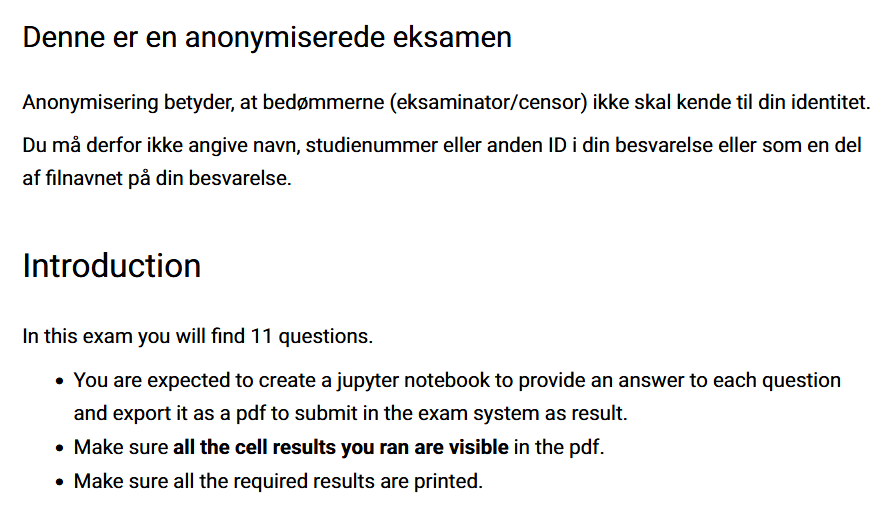

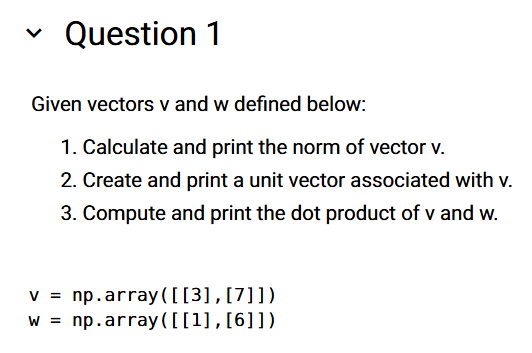

In [7]:
v = np.array([[3], [7]])
w = np.array([[1], [6]])

#1 norm of v:
norm_v=np.linalg.norm(v)
print ("Norm of v: ", norm_v)

#2 Unit vector
unit_vector_v=(v/norm_v)
print("The unit vector is: ",'\n', unit_vector_v)

#3 dot product
#Since they are column matrixes we needd to flatten the vectors
dot_prod = v.flatten() @ w.flatten()
print ("Dot product: ",dot_prod)

Norm of v:  7.615773105863909
The unit vector is:  
 [[0.3939193 ]
 [0.91914503]]
Dot product:  45


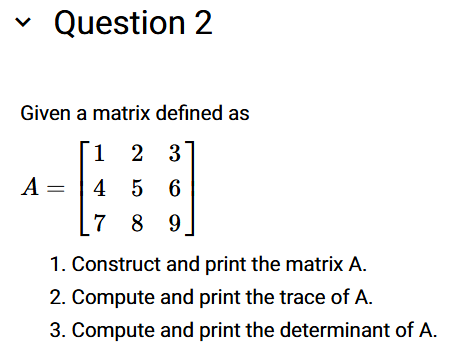

In [11]:
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

#1
print (A)

#2
A_trace = np.linalg.trace(A)
print ("Trace: ", A_trace)

#3
A_det = np.linalg.det(A)
print ("det: ", A_det)



[[1 2 3]
 [4 5 6]
 [7 8 9]]
Trace:  15
det:  0.0


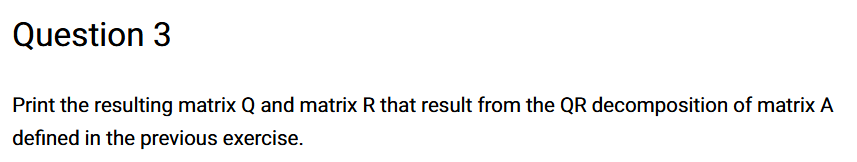

In [12]:
Q, R = np.linalg.qr(A)

print("Q (orthogonal):"); print(np.round(Q, 4))
print("\nR (upper triangular):"); print(np.round(R, 4))

Q (orthogonal):
[[-0.1231  0.9045  0.4082]
 [-0.4924  0.3015 -0.8165]
 [-0.8616 -0.3015  0.4082]]

R (upper triangular):
[[ -8.124   -9.6011 -11.0782]
 [  0.       0.9045   1.8091]
 [  0.       0.      -0.    ]]


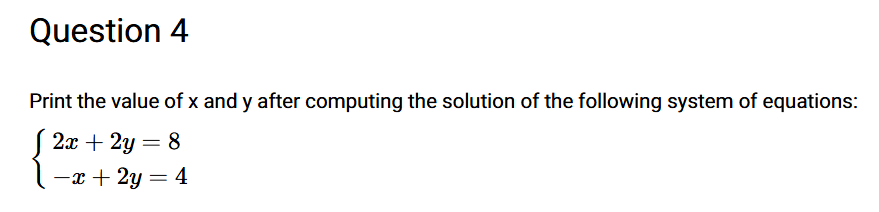

In [ ]:
A = np.array ([[2, 2],
               [-1, 2]])
b = ([8, 4])

x = np.linalg.solve(A,b)
print ("x = ",np.round(x[0],2))
print ("y = ",np.round(x[1],2), '\n')

x =  1.33
y =  2.67 



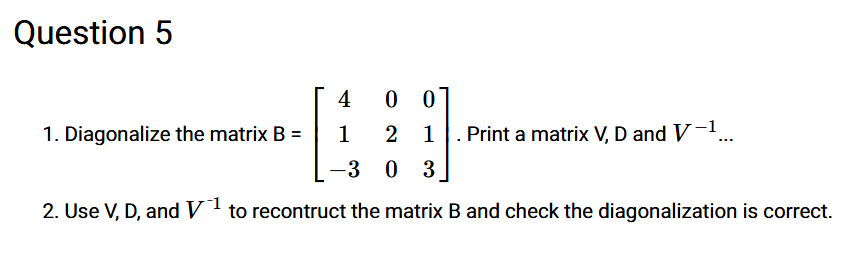

In [18]:
B = np.array ([[4, 0, 0],
               [1, 2, 1],
               [-3, 0, 3]])

eigenvalues, V = np.linalg.eig(B)
D   = np.diag(eigenvalues)
V_inv = np.linalg.inv(V)

print ("V: \n", np.round(V,4), "\nD: \n", np.round(D,4), "\nV^-1: \n", np.round(V_inv,4), '\n')

#To show the diagonalization is correct, we reconstruct and verify
B_rec = V @ D @ V_inv
print ("Reconstruction (V @ D @ V_inv): \n", B_rec)
print ("The matrix B: \n", B, '\n')

V: 
 [[ 0.      0.      0.3015]
 [ 1.      0.7071 -0.3015]
 [ 0.      0.7071 -0.9045]] 
D: 
 [[2. 0. 0.]
 [0. 3. 0.]
 [0. 0. 4.]] 
V^-1: 
 [[-2.      1.     -1.    ]
 [ 4.2426  0.      1.4142]
 [ 3.3166  0.      0.    ]] 

Reconstruction (V @ D @ V_inv): 
 [[ 4.  0.  0.]
 [ 1.  2.  1.]
 [-3.  0.  3.]]
The matrix B: 
 [[ 4  0  0]
 [ 1  2  1]
 [-3  0  3]] 



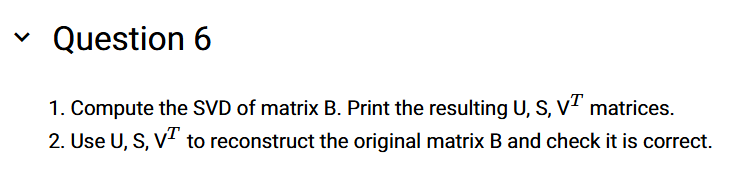

In [19]:
# 1. SVD:
U, S, Vt = np.linalg.svd(B)
#First we convert S from a 1D array to a diagonal matrix:
S_matrix = np.diag(S)
print ("U: \n", np.round(U,4), "\nS: \n", np.round (S_matrix,4), "\n Vt: \n", np.round(Vt,4), '\n')

# 2. Reconstruct and verify

#Now we reconstruct B:
B_verify2 = U @ S_matrix @ Vt
print ("B: \n", B , '\n')
print ("Verification (U @ S (matrix form) @ Vt) \n", np.round(B_verify2,2), '\n')


U: 
 [[-0.6828 -0.4213  0.597 ]
 [-0.1169 -0.7435 -0.6584]
 [ 0.7212 -0.5193  0.4584]] 
S: 
 [[5.4185 0.     0.    ]
 [0.     2.8751 0.    ]
 [0.     0.     1.5405]] 
 Vt: 
 [[-0.9249 -0.0432  0.3777]
 [-0.3028 -0.5172 -0.8005]
 [ 0.2299 -0.8548  0.4653]] 

B: 
 [[ 4  0  0]
 [ 1  2  1]
 [-3  0  3]] 

Verification (U @ S (matrix form) @ Vt) 
 [[ 4. -0.  0.]
 [ 1.  2.  1.]
 [-3.  0.  3.]] 



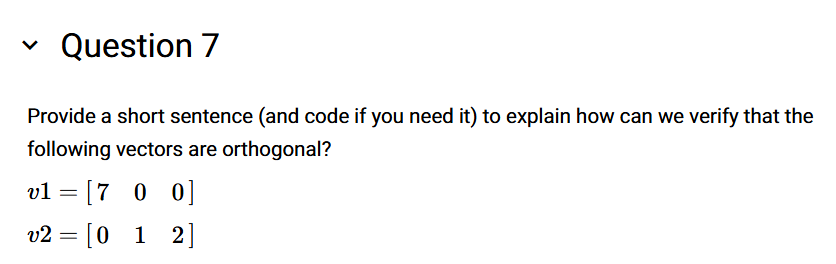

Two vectors are **orthogonal** if their dot product is zero — meaning they are perpendicular (90°).
So we can just find their dot product:

In [24]:
v1 = np.array ([7,0,0])
v2 = np.array ([0,1,2])

print ("Vectors v1 and v2 are orthogonal:",0 == np.dot(v1,v2))


Vectors v1 and v2 are orthogonal: True


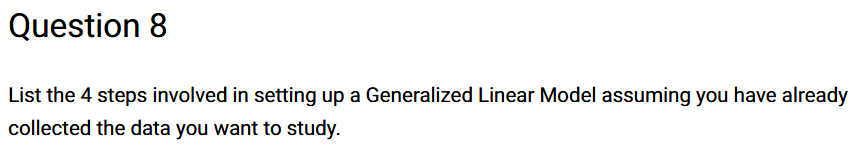

1. Define the model equation: $y = X\beta
2. Build the design matrix $X$ (add a column of ones for the intercept)
3. Write as matrix equation: $y = X\beta$
4. Solve: $\beta = (X^TX)^{-1}X^Ty$ using least squares (np.linalg.lstsq)

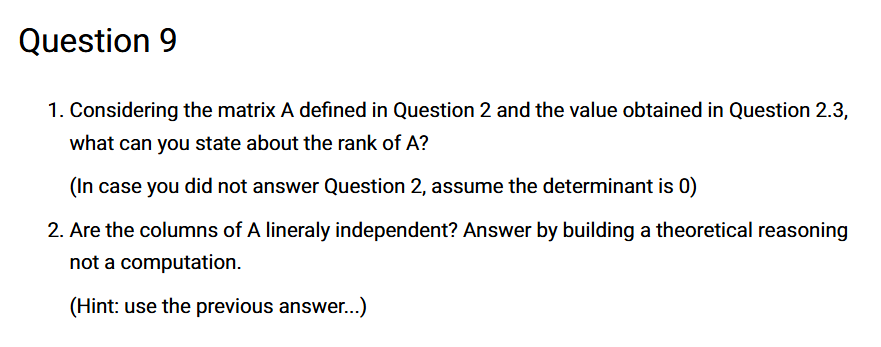

1. Since det = 0 at least one vector is redundant, which means that the rank < n. (rank(A) < columns (In this case 3))
2. If det = 0 and rank < n, A is linearly dependent

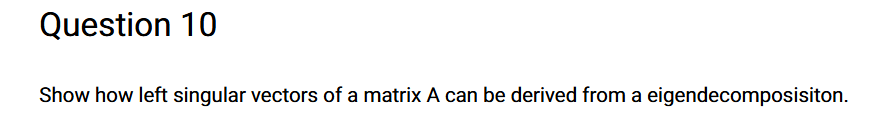

The left singular vectors of a matrix A is U from the formula $A=U\sum V^T$.
Can be derived from an eigendecomposition, by making a eigendecomposition of $AA^T$, which is exactly U.
in python it looks like this:

In [ ]:
evals, U = np.linalg.eigh(A @ A.T)

Basically, what it means to derive the left singular vectors of matrix A from an eigendecomposition, is to make a eigendecomposition of $AA^T$ 

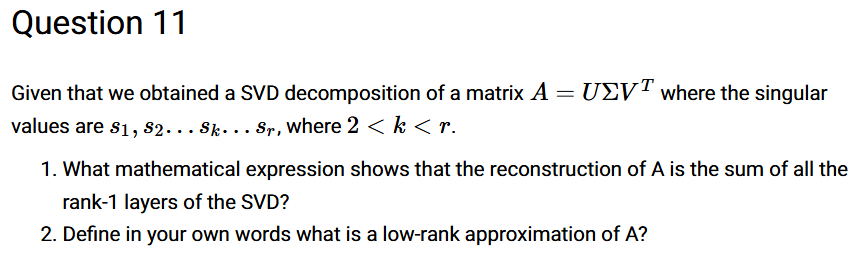

1. Full reconstruction of a:
$$A = \sum_{i=1}^{r} s_i \cdot u_i \cdot v_i^T$$
Low-rank approx:
$$\hat{A_k}=\sum_{i=1}^{k} s_i \cdot u_i \cdot v_i^T$$
2. Any matrix can be written as a sum of rank-1 matrices (outer products), weighted by the singular values. A low-rank approximation keeps only the $k$ most important terms, discarding the rest.